In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, roc_auc_score
import joblib
df    = pd.read_csv('../data/processed/deliveries_clean.csv')
X     = df.drop('is_delayed', axis=1)
y     = df['is_delayed']
model = joblib.load('../models/best_model.pkl')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
predictions   = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]
print(f"Model loaded: {type(model).__name__}")

Model loaded: LogisticRegression


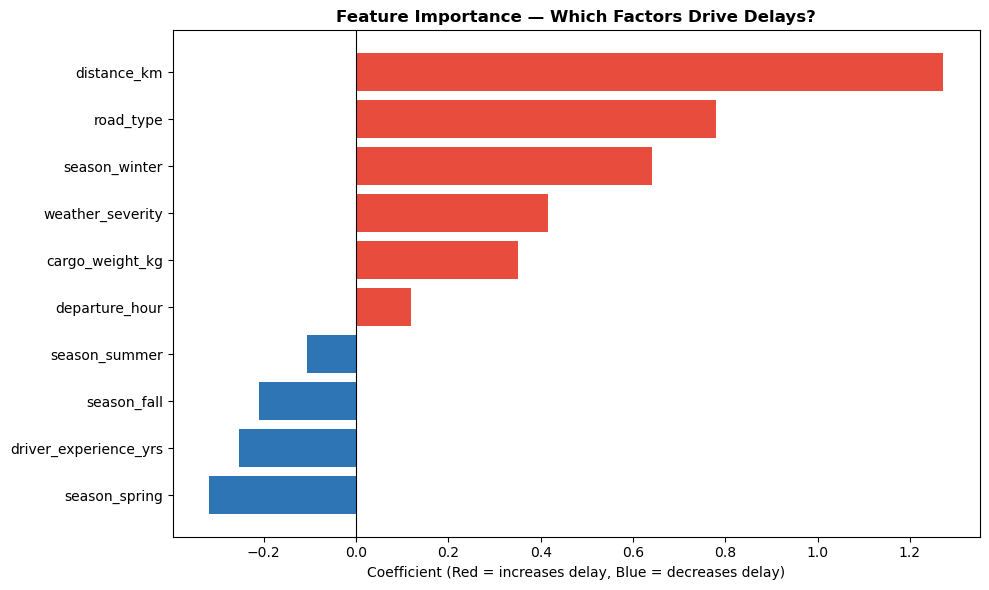

In [2]:
# Which features does the model rely on most?
feature_names = X.columns.tolist()
coefficients  = model.coef_[0]

importance_df = pd.DataFrame({'Feature':     feature_names,'Coefficient': coefficients}).sort_values('Coefficient', ascending=True)

colors = ['#E74C3C' if c > 0 else '#2E75B6'
          for c in importance_df['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'],
         importance_df['Coefficient'],
         color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Feature Importance — Which Factors Drive Delays?',
          fontweight='bold')
plt.xlabel('Coefficient (Red = increases delay, Blue = decreases delay)')
plt.tight_layout()
plt.savefig('../charts/chart8_feature_importance.png')
plt.show()

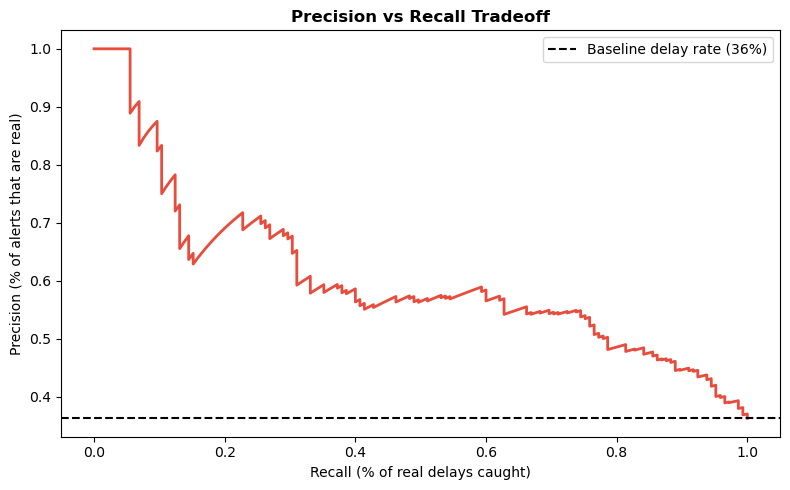

In [3]:
precision, recall, _ = precision_recall_curve(y_test, probabilities)
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='#E74C3C', linewidth=2)
plt.axhline(y=y_test.mean(), color='black', linestyle='--',
            label=f'Baseline delay rate ({y_test.mean():.0%})')
plt.xlabel('Recall (% of real delays caught)')
plt.ylabel('Precision (% of alerts that are real)')
plt.title('Precision vs Recall Tradeoff', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../charts/chart9_precision_recall.png')
plt.show()

In [5]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, predictions).ravel()
auc            = roc_auc_score(y_test, probabilities)

print("=" * 50)
print("FINAL PROJECT SUMMARY — JDI DELIVERY PREDICTOR")
print("=" * 50)

print(f"\nModel: {type(model).__name__}")
print(f"AUC-ROC: {auc:.3f}")

print(f"\nOut of 400 test deliveries:")
print(f"  Correctly predicted on time : {tn}")
print(f"  Correctly flagged as delayed: {tp}")
print(f"  False alarms                : {fp}")
print(f"  Missed delays               : {fn}")

print(f"\nIn plain English:")
print(f"  Out of every 100 real delays,")
print(f"  the model catches {tp/(tp+fn)*100:.0f} before the truck leaves.")

print(f"\nTop delay factors learned by model:")
coefs = pd.Series(model.coef_[0], index=X.columns)
top3  = coefs.abs().nlargest(3)
for feat, val in top3.items():
    direction = "increases" if coefs[feat] > 0 else "decreases"
    print(f"  {feat} {direction} delay risk")


FINAL PROJECT SUMMARY — JDI DELIVERY PREDICTOR

Model: LogisticRegression
AUC-ROC: 0.733

Out of 400 test deliveries:
  Correctly predicted on time : 211
  Correctly flagged as delayed: 58
  False alarms                : 44
  Missed delays               : 87

In plain English:
  Out of every 100 real delays,
  the model catches 40 before the truck leaves.

Top delay factors learned by model:
  distance_km increases delay risk
  road_type increases delay risk
  season_winter increases delay risk
